In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import pickle

In [2]:
# Load Background Solutions
with open("./numpyArr/Rgrid.pkl", "rb") as f:                        
    # binary read
    Rgrid = pickle.load(f)

with open("./numpyArr/PMSol.pkl", "rb") as f:                        
    # binary read
    PMSol = pickle.load(f)

with open("./numpyArr/H00Grid.pkl", "rb") as f:                        
    # binary read
    H00Grid = pickle.load(f)

with open("./numpyArr/NuGrid.pkl", "rb") as f:                        
    # binary read
    NuGrid = pickle.load(f)

with open("./numpyArr/PMSol.pkl", "rb") as f:
    PMSol = pickle.load(f)

with open("./numpyArr/Source_concatGrid.pkl", "rb") as f:
    Source_concatGrid = pickle.load(f)

In [3]:
# EOS (energy density vs pressure)
def EnergyEOS(p, K):
    rr = ((1 + np.sqrt(4 * K * p)) ** 2 - 1) / (4 * K)
    return rr

G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
cm2km = 1e5

def cgs_to_geom(p_cgs, n, K_cgs, eos=EnergyEOS):
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2
    K_geom = K_cgs / G_cgs**(1 / n) / c_cgs**(2 - 2 / n) / cm2km**(2 / n)
    rho_geom = eos(p_geom, K_geom)
    return K_geom, p_geom, rho_geom

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]


In [4]:
# Equation for 
def h01pp_rhs(r, y, p_r, rho_r, drho, lamb_r, r_grid, source_arr):
    eL = np.exp(lamb_r)
    pi = np.pi
    r2 = r * r
    r3 = r2 * r
    r4 = r2 * r2
    r6 = r3 * r3

    A = (
        -1.0 - 3.0 * eL + 3.0 * eL * eL + eL * eL * eL
        + 96.0 * (eL * eL) * (-5.0 + 2.0 * eL) * (pi**2) * r4 * (p_r**2)
        + 512.0 * (eL**3) * (pi**3) * r6 * (p_r**3)
        - 20.0 * eL * (-1.0 + eL) * pi * r2 * rho_r
        + 4.0 * eL * pi * r2 * p_r * (15.0 - 9.0 * eL + 6.0 * (eL * eL) - 40.0 * eL * pi * r2 * rho_r)
        + 8.0 * eL * pi * r3 * drho
    )

    D = -1.0 + eL + 8.0 * eL * pi * r2 * p_r
    if r2 == 0.0 or D == 0.0 or not np.isfinite(D):
        raise ZeroDivisionError(f"Singular denominator at r={r}. Adjust domain or background.")

    coeff = 1.0 + eL + 4.0 * eL * pi * r2 * p_r - 4.0 * eL * pi * r2 * rho_r
    source_val = np.interp(r, r_grid, source_arr)

    y1, y2 = y  # y1 = h01, y2 = h01'
    y1_src = (A / D) / r2
    y2_src = -coeff / r

    return np.array([y2, source_val + y1_src * y1 + y2_src * y2], dtype=float)

# Minimal fixed-step RK4 integrator
def rk4_step(f, x, y, h, **kwargs):
    k1 = f(x, y, **kwargs)
    k2 = f(x + 0.5 * h, y + 0.5 * h * k1, **kwargs)
    k3 = f(x + 0.5 * h, y + 0.5 * h * k2, **kwargs)
    k4 = f(x + h, y + h * k3, **kwargs)
    return y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [5]:
import numpy as np
from tqdm import tqdm

# --- 改：RHS 内部对背景做插值，保证 RK4 的中点评估正确 ---
def h01_rhs_interp(r, y, r_grid, PArr, RhoArr, LambArr, DrhoArr, source_arr):
    pi = np.pi

    # background interpolation at this r
    p_r   = np.interp(r, r_grid, PArr)
    rho_r = np.interp(r, r_grid, RhoArr)
    lamb_r= np.interp(r, r_grid, LambArr)
    drho  = np.interp(r, r_grid, DrhoArr)
    S     = np.interp(r, r_grid, source_arr)

    eL = np.exp(lamb_r)
    r2 = r*r
    r3 = r2*r
    r4 = r2*r2
    r6 = r3*r3

    A = (
        -1.0 - 3.0 * eL + 3.0 * eL * eL + eL * eL * eL
        + 96.0 * (eL * eL) * (-5.0 + 2.0 * eL) * (pi**2) * r4 * (p_r**2)
        + 512.0 * (eL**3) * (pi**3) * r6 * (p_r**3)
        - 20.0 * eL * (-1.0 + eL) * pi * r2 * rho_r
        + 4.0 * eL * pi * r2 * p_r * (15.0 - 9.0 * eL + 6.0 * (eL * eL) - 40.0 * eL * pi * r2 * rho_r)
        + 8.0 * eL * pi * r3 * drho
    )

    D = -1.0 + eL + 8.0 * eL * pi * r2 * p_r

    # 数值安全：不要用 r2 == 0.0 这种比较
    if r < r_grid[0] or r2 <= 0.0 or (not np.isfinite(D)) or abs(D) < 1e-30:
        raise ZeroDivisionError(f"Singular/ill-conditioned at r={r} (D={D}). Use eps>0 and smooth background.")

    coeff = 1.0 + eL + 4.0 * eL * pi * r2 * p_r - 4.0 * eL * pi * r2 * rho_r

    y1, y2 = y  # y1=h01, y2=h01'
    y1_src = (A / D) / r2
    y2_src = -coeff / r

    return np.array([y2, S + y1_src * y1 + y2_src * y2], dtype=float)


def rk4_step(f, x, y, h, **kwargs):
    k1 = f(x, y, **kwargs)
    k2 = f(x + 0.5*h, y + 0.5*h*k1, **kwargs)
    k3 = f(x + 0.5*h, y + 0.5*h*k2, **kwargs)
    k4 = f(x + h,     y + h*k3,     **kwargs)
    return y + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)


def integrate_on_grid(y0, r_grid, PArr, RhoArr, LambArr, DrhoArr, source_arr):
    sol = np.zeros((len(r_grid), 2), dtype=float)
    sol[0] = y0
    y = y0.copy()
    for j in range(len(r_grid)-1):
        r  = r_grid[j]
        h  = r_grid[j+1] - r_grid[j]
        y  = rk4_step(
            h01_rhs_interp, r, y, h,
            r_grid=r_grid, PArr=PArr, RhoArr=RhoArr, LambArr=LambArr, DrhoArr=DrhoArr,
            source_arr=source_arr
        )
        sol[j+1] = y
        
    return sol


In [6]:
arrLenAll = []
H01Sol_Grid = []       # full / hom / particular 
H01Hom_Grid = []
H01Part_Grid = []

for nnn in tqdm(range(0, 20)):
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    RhoArr  = EnergyEOS(PArr, K)
    LambArr = np.log(RArr/(RArr - 2*MArr))
    NuArr   = NuGrid[solToUseID]

    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)

    H00r  = np.array(H00Grid[solToUseID][:, 0])
    DH00r = np.array(H00Grid[solToUseID][:, 1])

    arrLen = min(len(l) for l in [RArr, PArr, MArr, RhoArr, LambArr, NuArr, DrhoArr, H00r, DH00r])
    arrLenAll.append(arrLen)

    SurfaceIndex = arrLen - 4

    # Region within the surface
    r_grid = RArr[:SurfaceIndex]
    P_use  = PArr[:SurfaceIndex]
    Rho_use= RhoArr[:SurfaceIndex]
    Lamb_use=LambArr[:SurfaceIndex]
    Drho_use=DrhoArr[:SurfaceIndex]

    
    # Source term, with a negative sign.
    source_use = -Source_concatGrid[solToUseID][:SurfaceIndex]

    # starting radius
    eps = r_grid[0]
    
    # if eps <= 0.0:
    #     eps = r_grid[1]
    #     r_grid   = r_grid[1:]
    #     P_use    = P_use[1:]
    #     Rho_use  = Rho_use[1:]
    #     Lamb_use = Lamb_use[1:]
    #     Drho_use = Drho_use[1:]
    #     source_use = source_use[1:]
    #     eps = r_grid[0]

    # Initial condition
    y0 = np.array([eps**2, 2.0*eps], dtype=float)

    # 1) homogeneous
    source0 = np.zeros_like(source_use)
    sol_h = integrate_on_grid(y0, r_grid, P_use, Rho_use, Lamb_use, Drho_use, source0)

    # 2) full
    sol_full = integrate_on_grid(y0, r_grid, P_use, Rho_use, Lamb_use, Drho_use, source_use)

    # 3) particular = full - hom
    sol_p = sol_full - sol_h

    H01Hom_Grid.append(sol_h)
    H01Sol_Grid.append(sol_full)
    H01Part_Grid.append(sol_p)


100%|██████████| 20/20 [03:17<00:00,  9.89s/it]


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 60.65it/s]


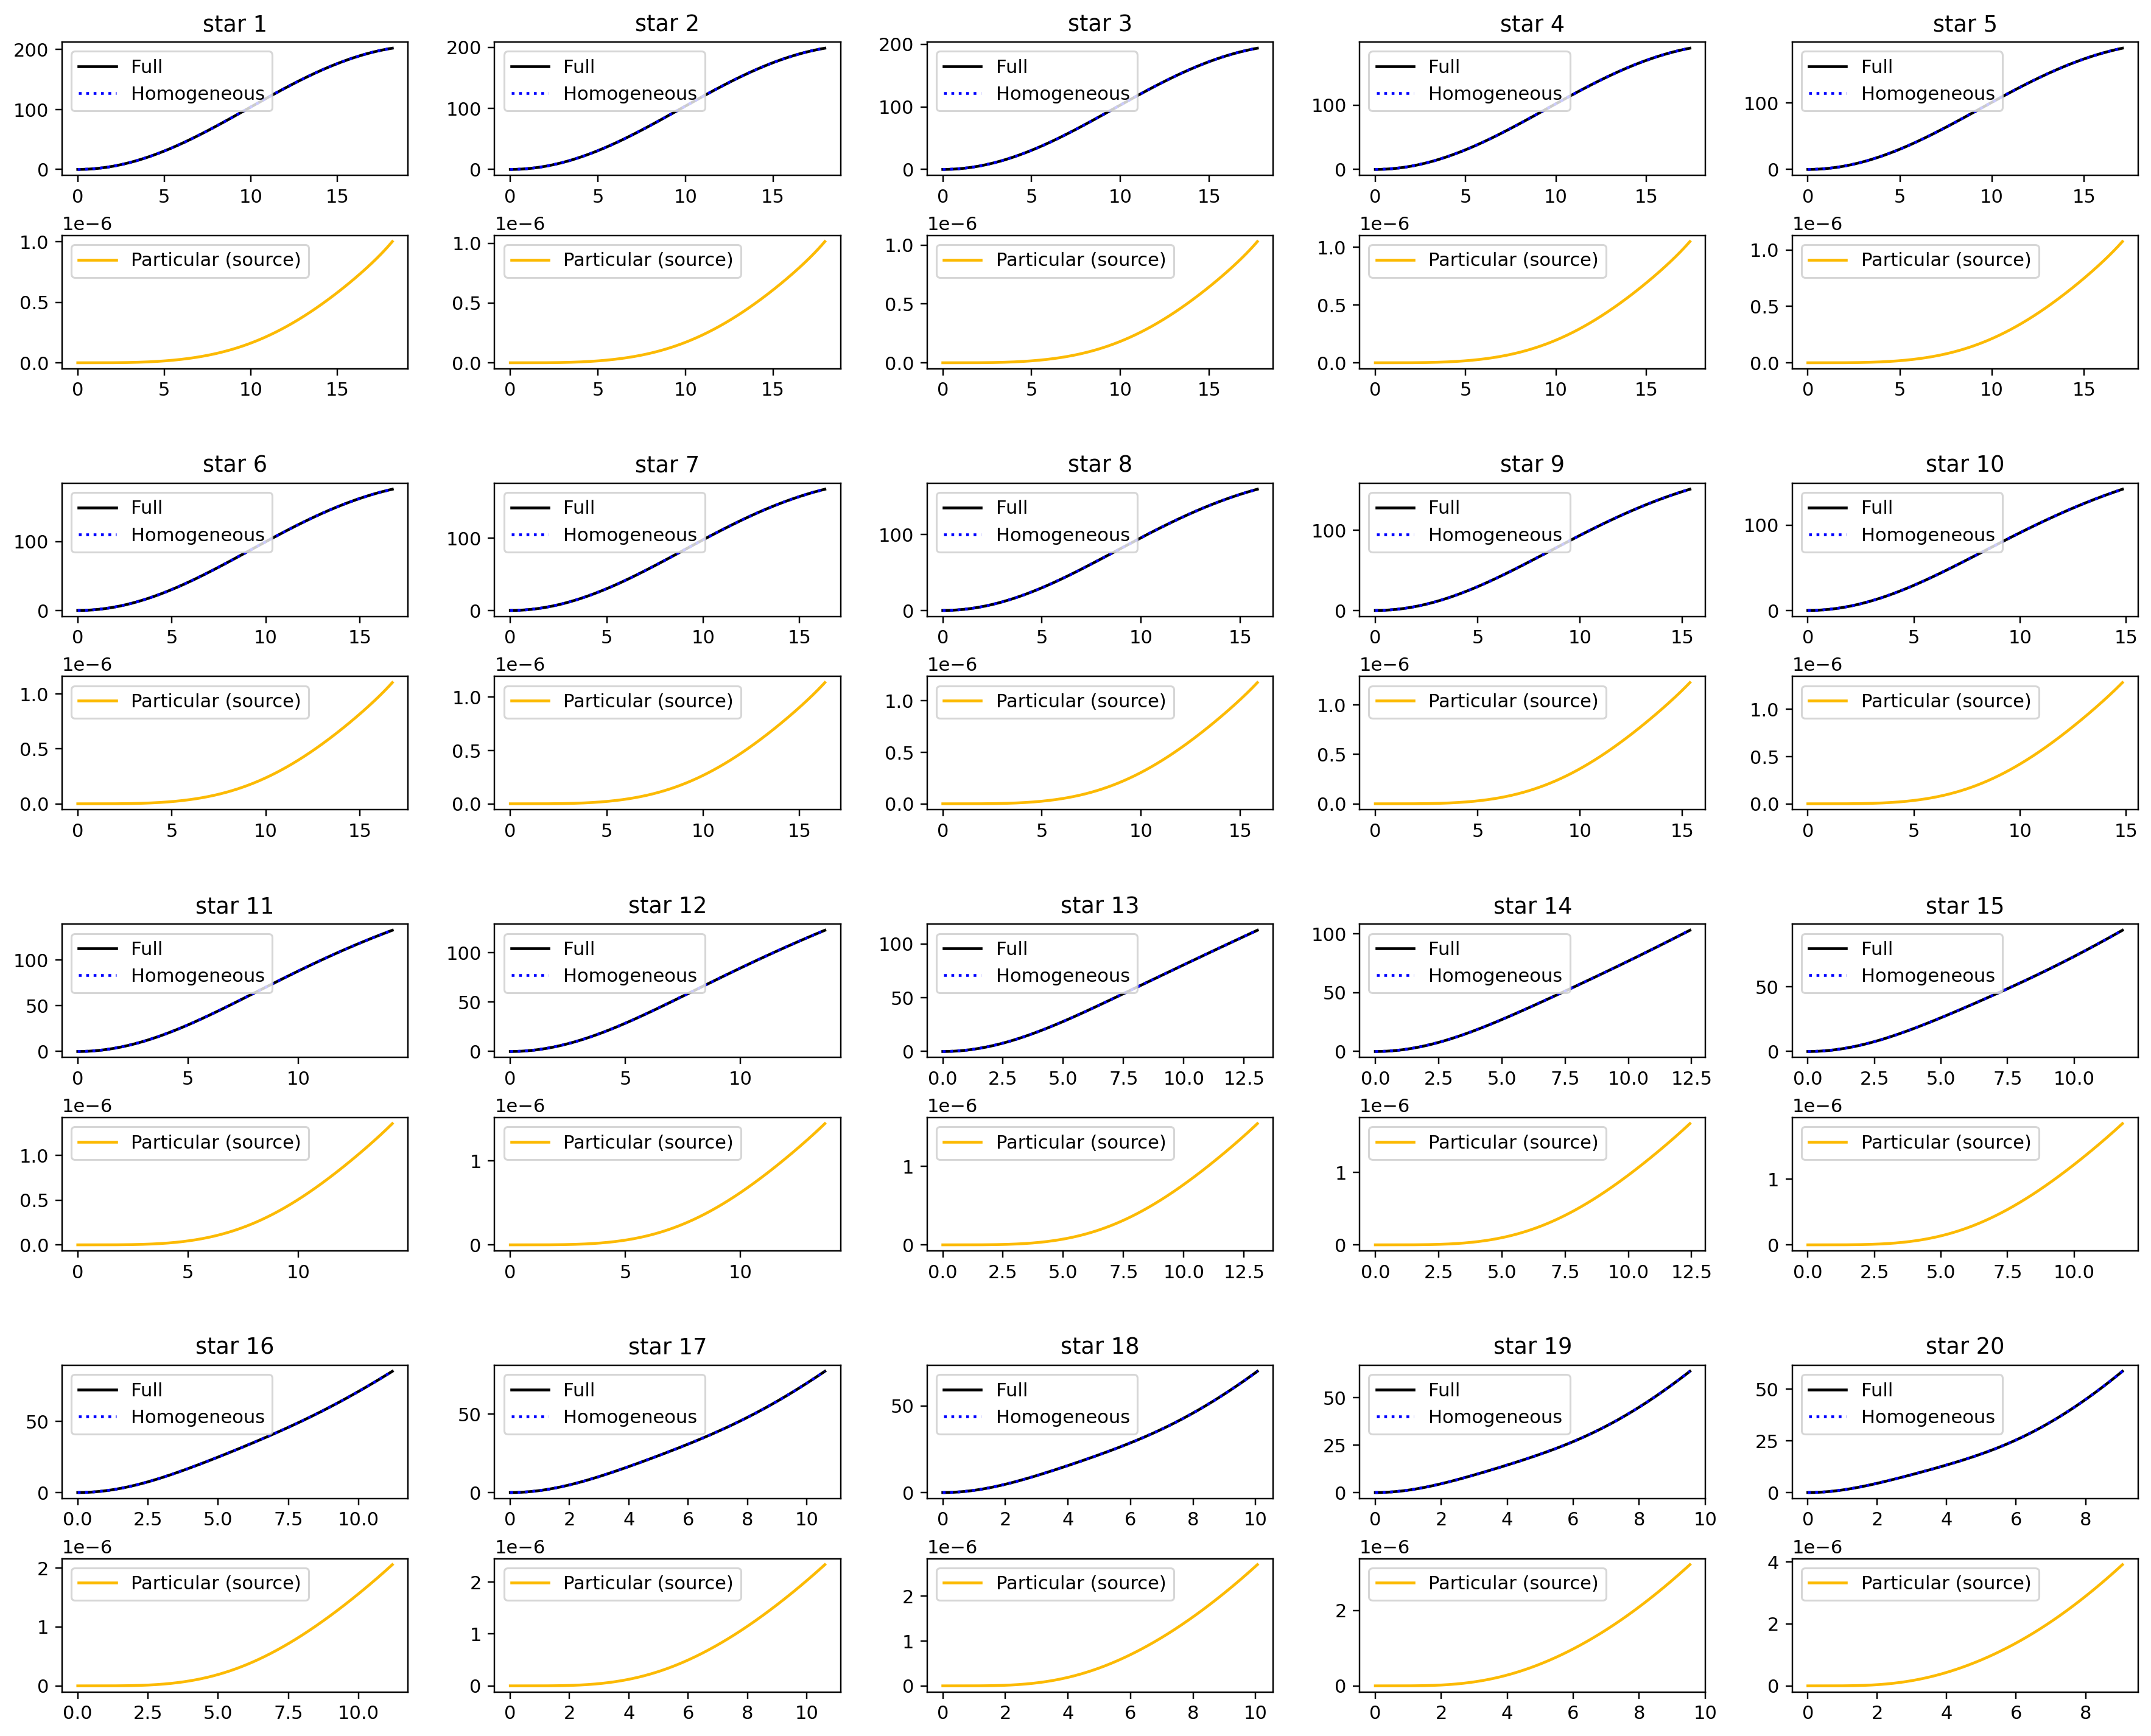

In [7]:
fig = plt.figure(figsize=(20, 16), dpi=220)
outer = fig.add_gridspec(4, 5, wspace=0.25, hspace=0.35)

for nnn in tqdm(range(0, 20)):
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    # ax = axs[nnn // 5, nnn % 5]

    # --- dividing in subplots ---
    inner = outer[nnn // 5, nnn % 5].subgridspec(
        2, 1, height_ratios=[1, 1], hspace=0.45
    )
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    ax_top.plot(
        RArr[:SurfaceIndex],
        H01Sol_Grid[solToUseID][:SurfaceIndex][:,0],
        label="Full",
        color="black",
        lw=1.5,
    )
    ax_top.plot(
        RArr[:SurfaceIndex],
        H01Hom_Grid[solToUseID][:SurfaceIndex][:,0],
        label="Homogeneous",
        color="blue",
        ls = ":",
        lw=1.5,
    )
    ax_top.set_title(f"star {nnn+1}")
    # ax_top.set_yscale("log")
    ax_top.legend()

    ax_bot.plot(
        RArr[:SurfaceIndex],
        H01Part_Grid[solToUseID][:SurfaceIndex][:,0],
        label="Particular (source)",
        color="#fcba03",
        lw=1.5,
    )

    ax_bot.legend()


100%|██████████| 20/20 [00:00<00:00, 138.97it/s]


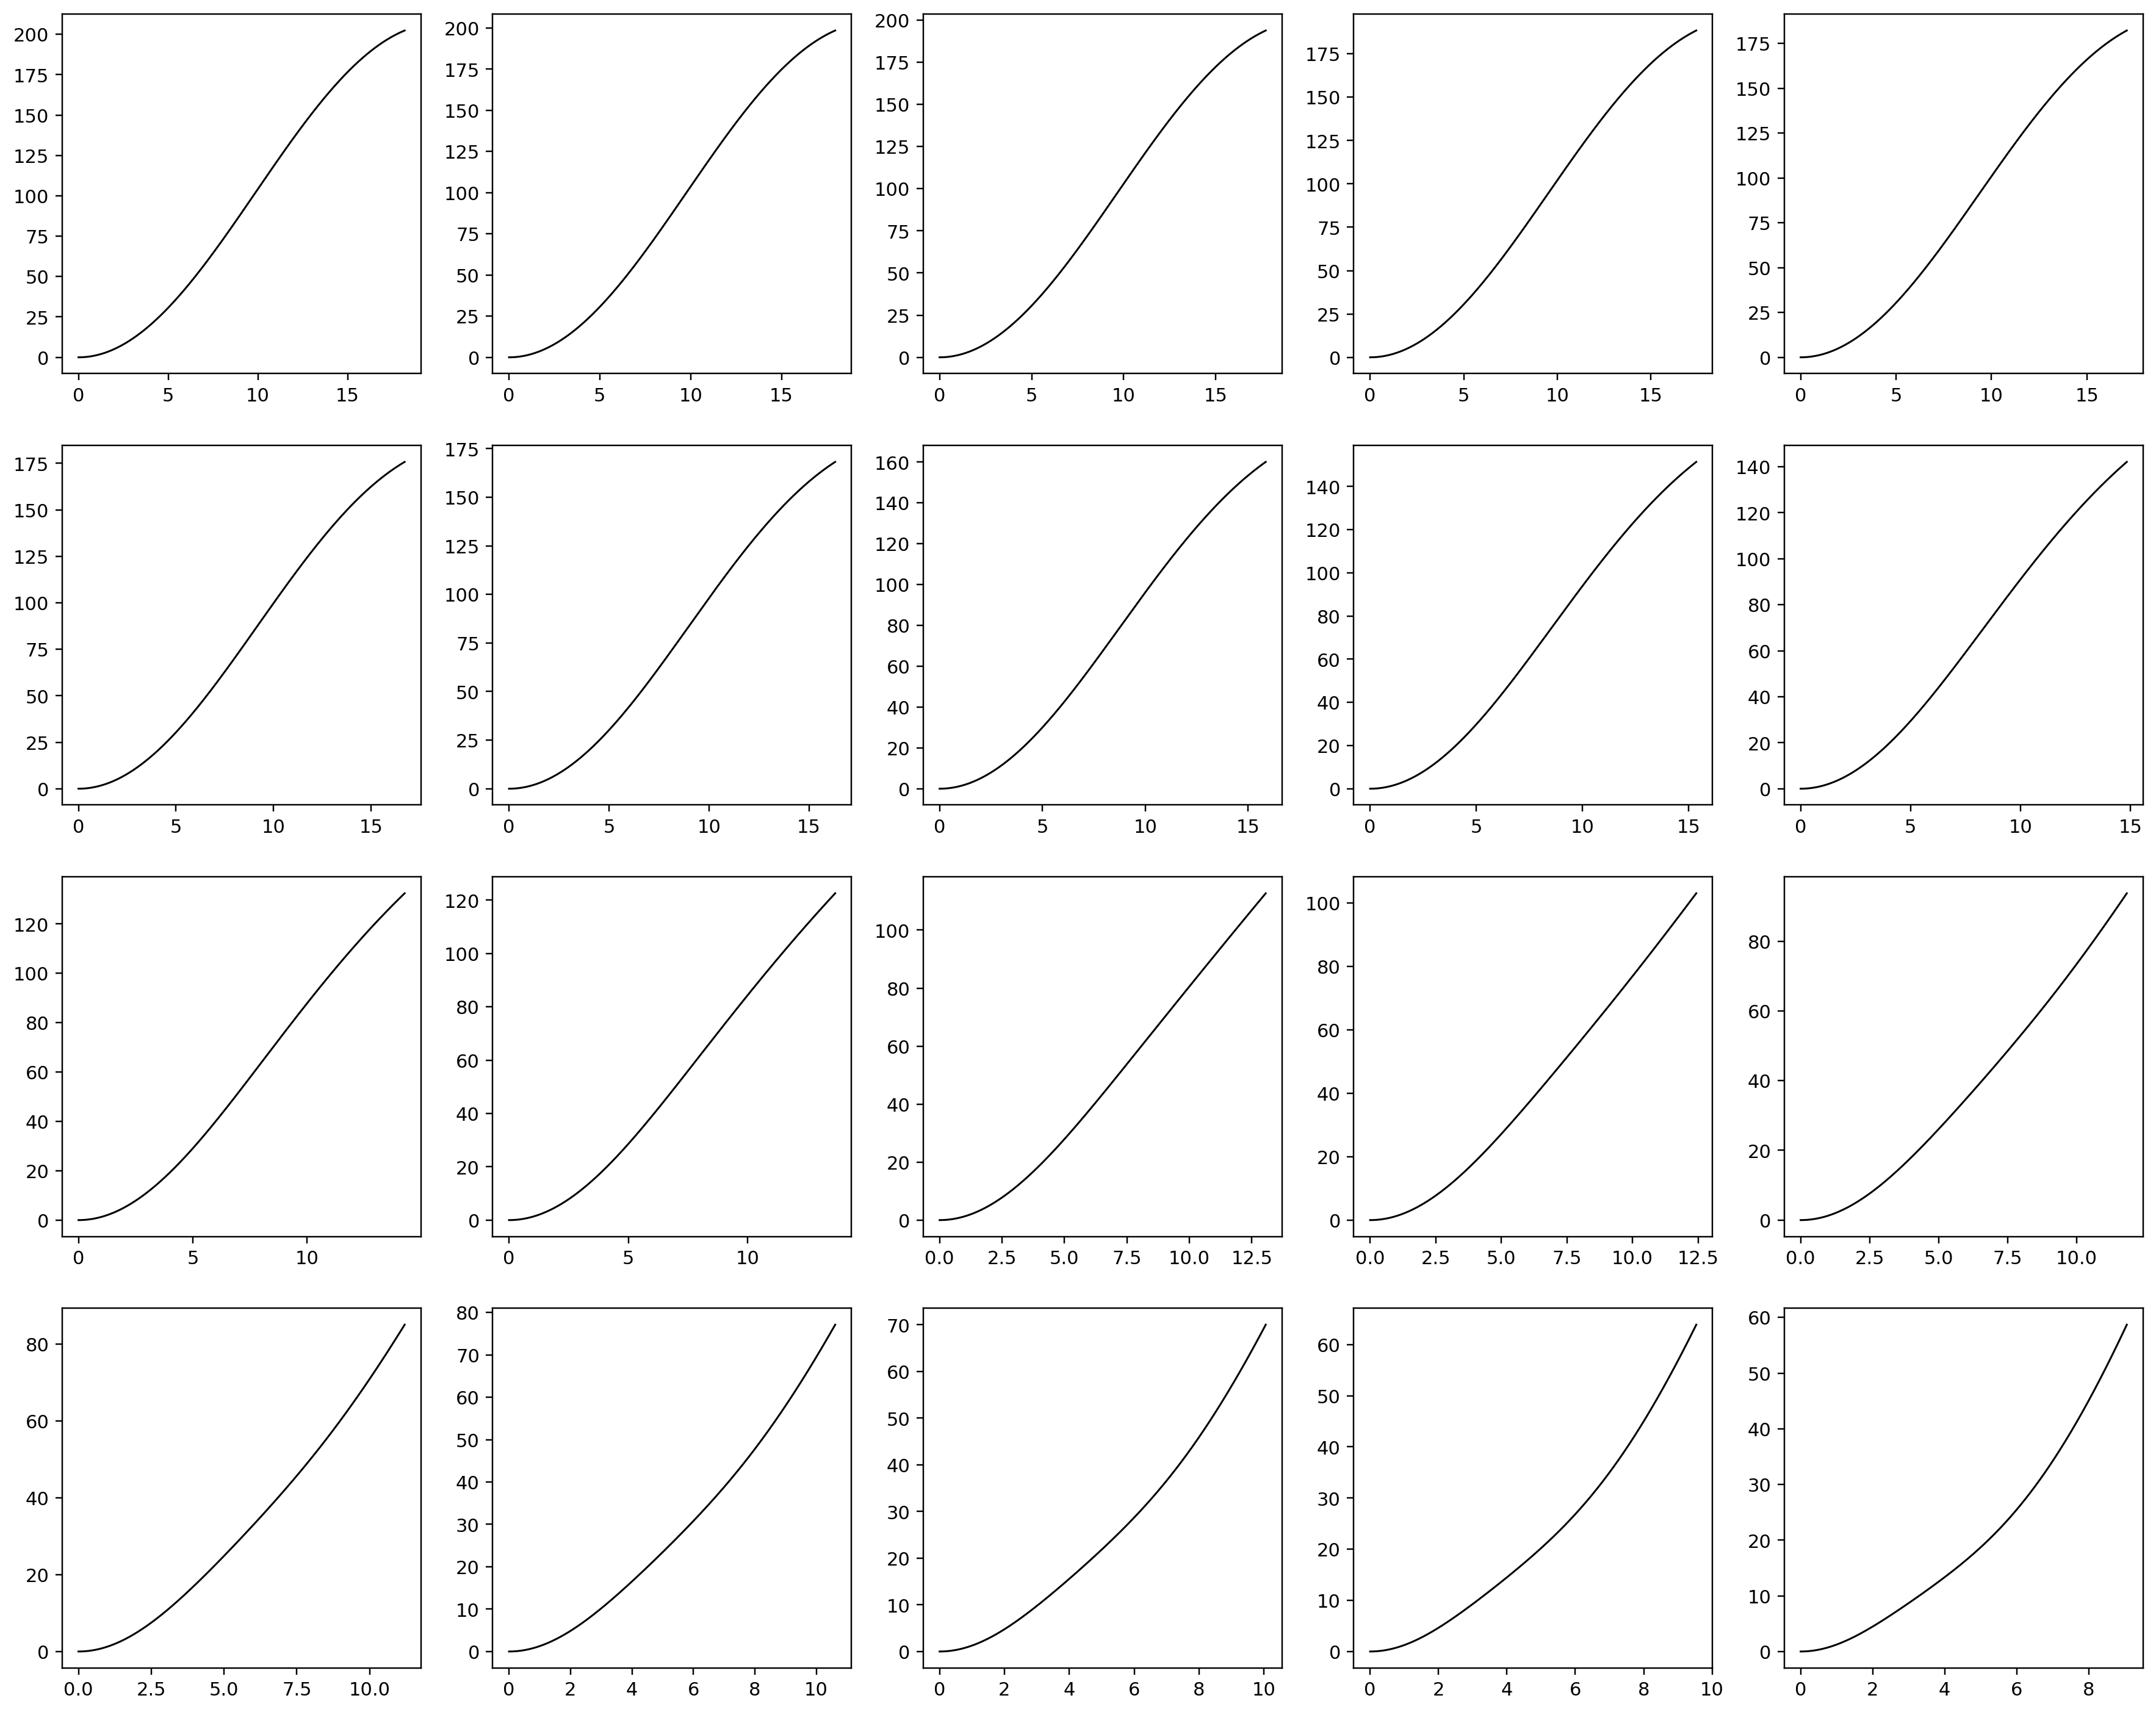

In [8]:
fig, axs = plt.subplots(4, 5, figsize=(20, 16), dpi=220)

for nnn in tqdm(range(0, 20)):
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    ax = axs[nnn // 5, nnn % 5]

    ax.plot(
        RArr[:SurfaceIndex],
        H01Sol_Grid[solToUseID][:SurfaceIndex][:,0],
        label="concat",
        color="black",
        lw=1,
    )



## Matching the surface boundary condition

We see that the homogeneous and full equation has very small difference with the initial condition that we applied. We are aware that there is one scaling degree of freedom that we can apply to the whole equation. (if we don't consider the boundary conditions) We however need to apply the continuous boundary condition of the first order terms at the stellar surface for both the zeroth and first order derivatives.

In [ ]:
from scipy.special import hyp2f1

ExteriorGrid_1stOrder = []
ExteriorGrid_1stOrderP = []

L = 2

for nnn in tqdm(range(0, 20)):

    solToUseID = nnn

    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    SurfaceIndex = arrLenAll[solToUseID] - 4

    # Region within the surface
    r_use = RArr[:SurfaceIndex]
    r_extended = np.arange(r_use[-1], 2 * r_use, 10**(-3.5))
    P_use  = PArr[:SurfaceIndex]
    M_use = MArr[:SurfaceIndex]
    
    # Source term, with a negative sign.
    source_use = -Source_concatGrid[solToUseID][:SurfaceIndex]

    # rm = r_use/M_use
    mr = M_use/r_use

    # f_minus = (1 - rm)**(L)
    f_plus = (1 - mr)**(L+1)

    hypF_plus = hyp2f1(L+1, L+3, 2*L+2, mr)

    ExteriorGrid_1stOrder.append(f_plus * hypF_plus * M_use)

    ext_star_grad = np.gradient(ExteriorGrid_1stOrder[solToUseID][:SurfaceIndex], RArr[:SurfaceIndex])
    ExteriorGrid_1stOrderP.append(ext_star_grad)


100%|██████████| 20/20 [00:00<00:00, 73.78it/s]


100%|██████████| 20/20 [00:00<00:00, 368.50it/s]


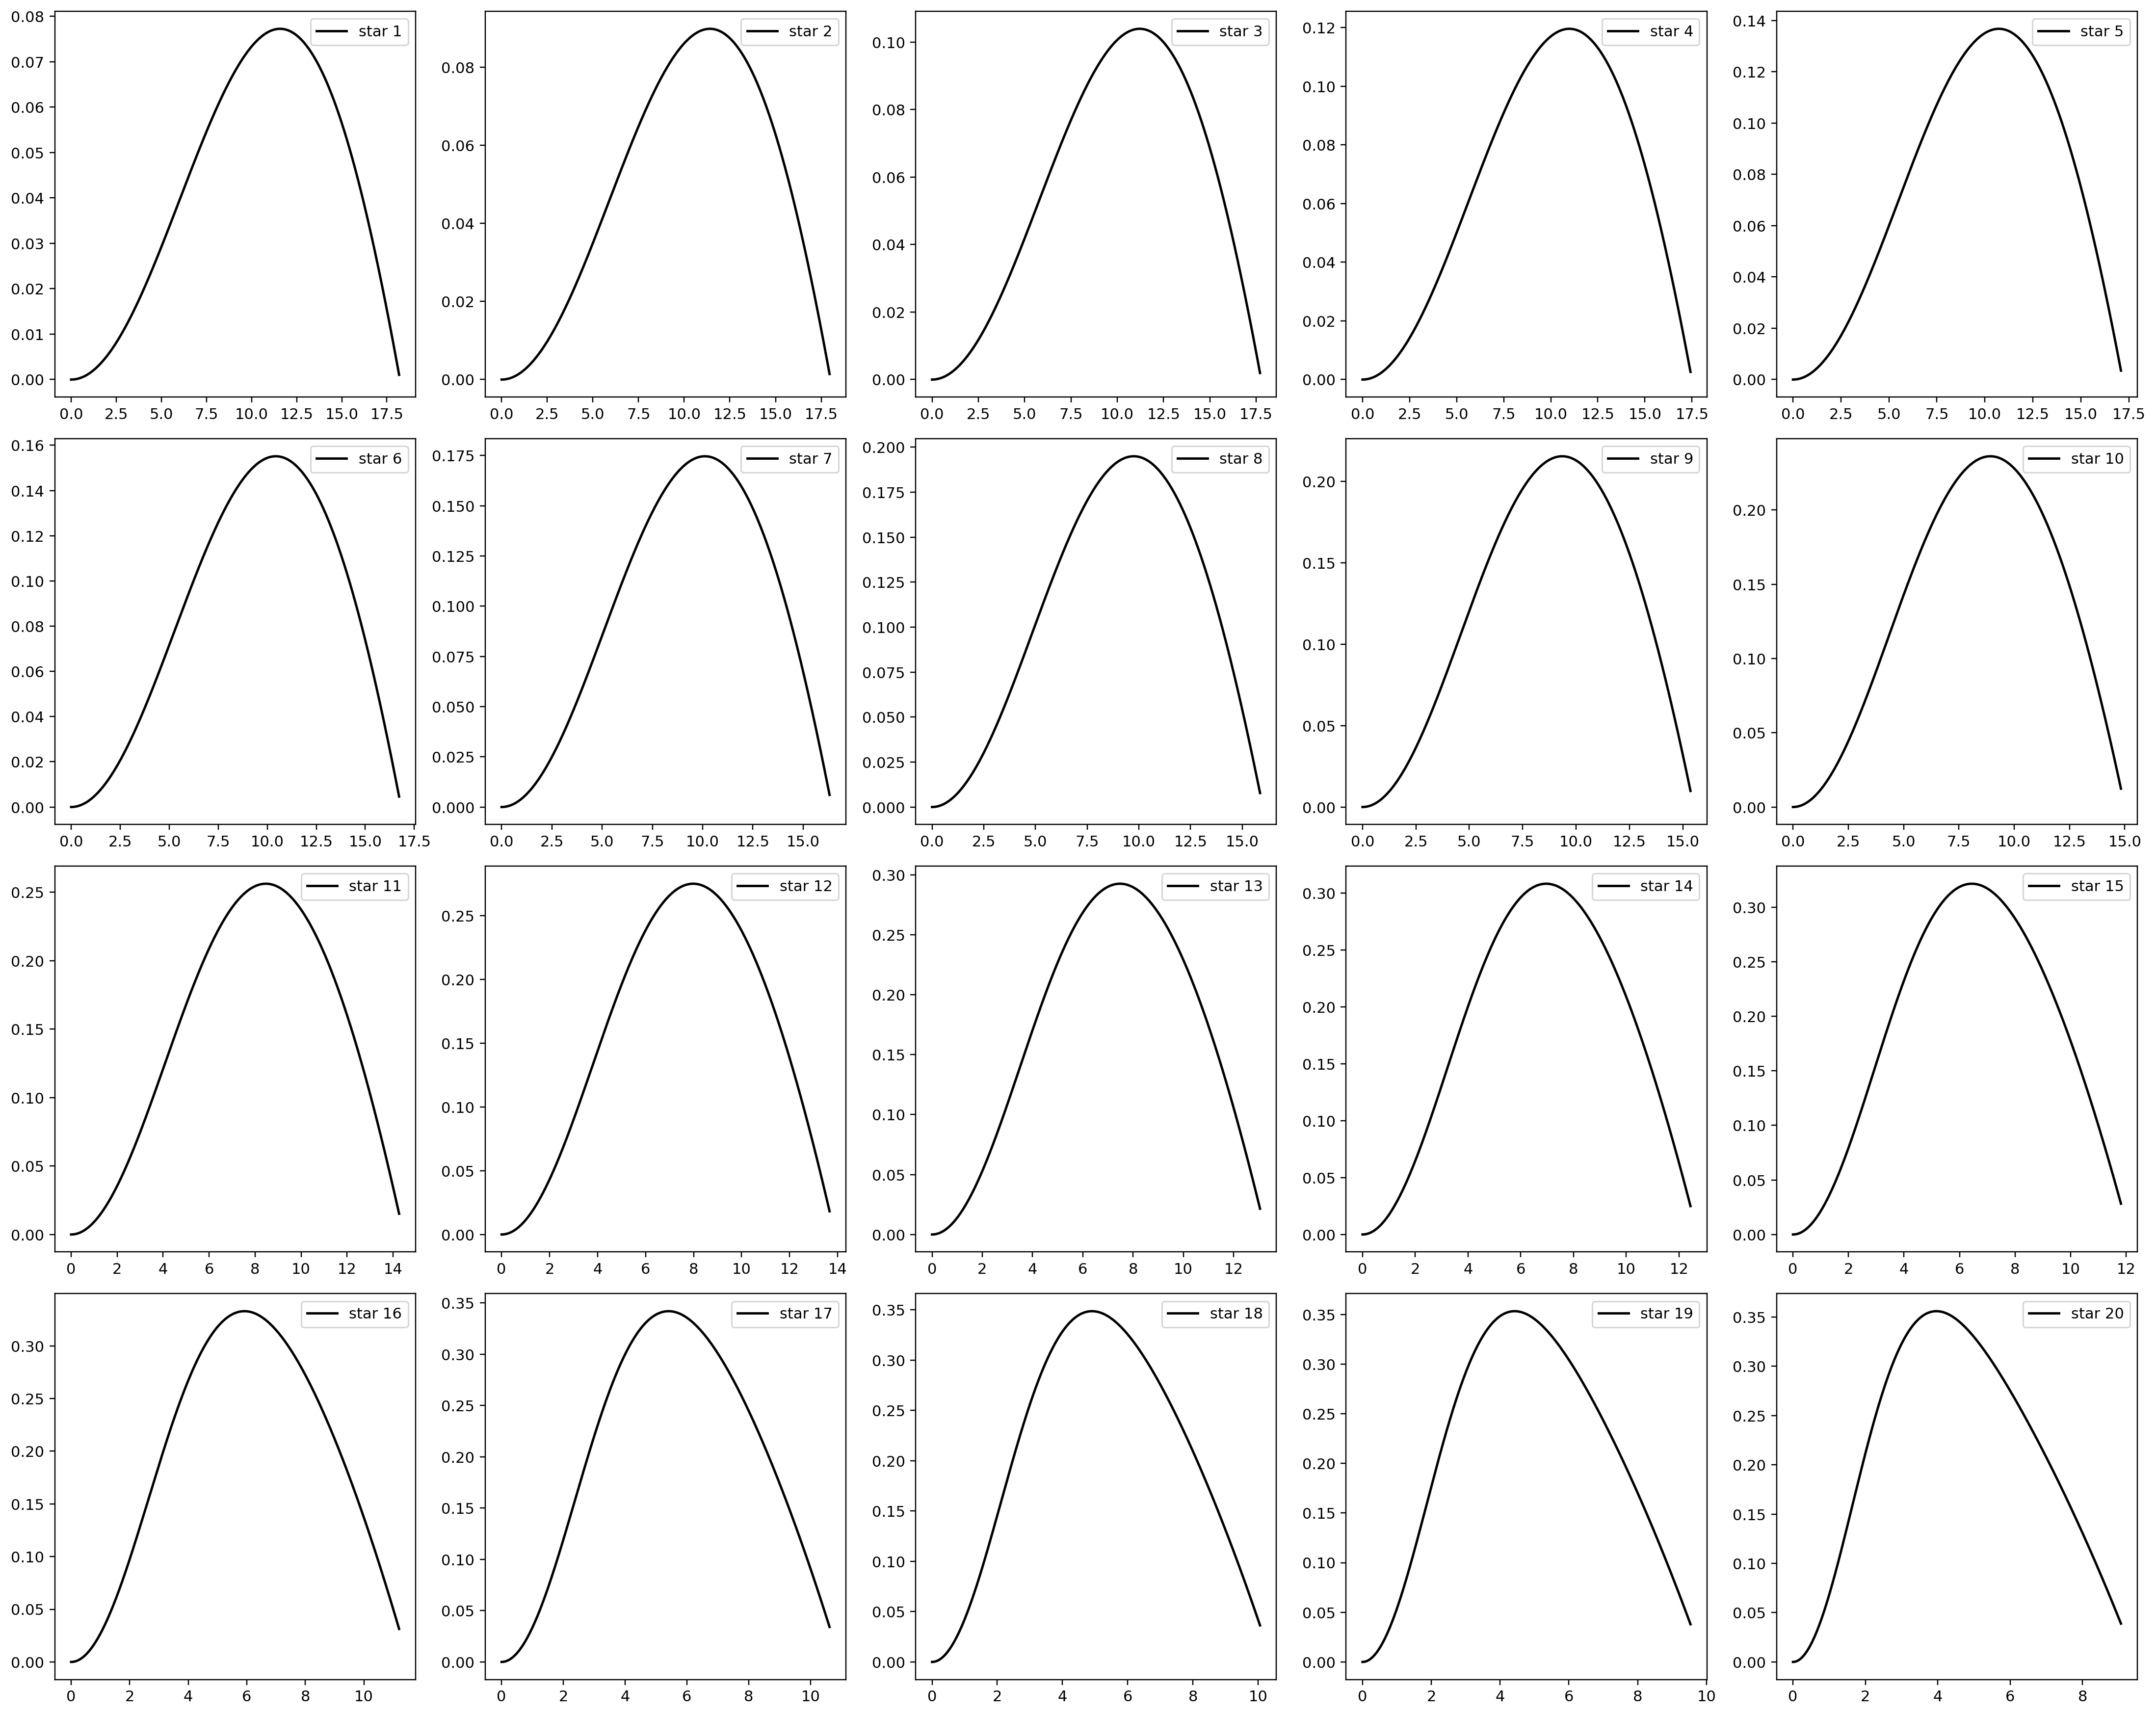

In [43]:
fig, axs = plt.subplots(4, 5, figsize=(20, 16), dpi=220)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)
    ax = axs[nnn // 5, nnn % 5]

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    ext_star = ExteriorGrid_1stOrder[solToUseID][:SurfaceIndex]
    ext_star_grad = ExteriorGrid_1stOrderP[solToUseID][:SurfaceIndex]

    # print(ext_star_grad.shape)

    # ax.plot(
    #     RArr[:SurfaceIndex],
    #     ext_star,
    #     label=f"star {nnn + 1}",
    #     color="black",
    #     lw=1.6,
    # )

    ax.plot(
        RArr[:SurfaceIndex],
        ext_star_grad,
        label=f"star {nnn + 1}",
        color="black",
        lw=1.6,
    )

    ax.legend()
    # ax.set_yscale("log")

fig.tight_layout()
plt.show()


Here we solve the set of linear equations to match the boundary condition
\begin{align}
&A_0 h_{01}^{\text{hom}}(R) +  h_{01}^{\text{p}}(R) = \mathbb{I}_{lm}^{(1)}MH_l^R(R)\\[10pt]
&A_0 (h_{01}^{\text{hom}})'(R) + (h_{01}^{\text{p}})'(R) = \mathbb{I}_{lm}^{(1)}(MH_l^R)'(R)
\end{align}

In [51]:
A0_Arr = []
I2m_Arr = []

for nnn in tqdm(range(0, 20)):
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    SurfaceIndex = arrLenAll[solToUseID] - 4

    h01_star_full = H01Sol_Grid[solToUseID][:SurfaceIndex]       # full / hom / particular 
    h01_star_hom = H01Hom_Grid[solToUseID][:SurfaceIndex] 
    h01_star_part = H01Part_Grid[solToUseID][:SurfaceIndex] 

    h01full_R = h01_star_full[-1]
    h01hom_R = h01_star_hom[-1]
    h01part_R = h01_star_part[-1]

    ext_star_R = ExteriorGrid_1stOrder[solToUseID][:SurfaceIndex][-1]
    ext_star_p_R = ExteriorGrid_1stOrderP[solToUseID][:SurfaceIndex][-1]

    print(h01full_R, h01hom_R, h01part_R) #, ext_star_R, ext_star_p_R)
    
    # Calculating A0
    A0_star = (ext_star_p_R * h01part_R[0] - ext_star_R * h01part_R[1]) / (h01hom_R[1] * ext_star_R - h01hom_R[0] * ext_star_p_R)
    A0_Arr.append(A0_star)

    I2m_star = (h01hom_R[1] * h01part_R[0] - h01hom_R[0] * h01part_R[1]) / (h01hom_R[1] * ext_star_R - h01hom_R[0] * ext_star_p_R)
    I2m_Arr.append(I2m_star)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 84.60it/s]

[202.32438222   4.61645203] [202.32438122   4.61645186] [1.00156740e-06 1.70842767e-07]
[198.45441183   4.84935568] [198.45441082   4.84935551] [1.01501001e-06 1.73340656e-07]
[193.77616816   5.11549168] [193.77616712   5.1154915 ] [1.03137484e-06 1.76366398e-07]
[188.44853831   5.42398433] [188.44853726   5.42398415] [1.05094716e-06 1.80035691e-07]
[182.18119498   5.77047019] [182.18119391   5.77047001] [1.07445996e-06 1.84514585e-07]
[175.76656327   6.18538436] [175.76656217   6.18538417] [1.10273254e-06 1.89985280e-07]
[168.20668094   6.63792026] [168.20667981   6.63792007] [1.13659192e-06 1.96708942e-07]
[160.08792313   7.14789599] [160.08792196   7.14789579] [1.17725480e-06 2.05019732e-07]
[151.37110408   7.71091878] [151.37110286   7.71091857] [1.22595728e-06 2.15339276e-07]
[142.09602442   8.31878303] [142.09602314   8.3187828 ] [1.28426421e-06 2.28248725e-07]
[132.42105612   8.96432348] [132.42105477   8.96432323] [1.35548385e-06 2.44586007e-07]
[122.57099119   9.63766396] [122

100%|██████████| 20/20 [00:00<00:00, 226.54it/s]


-8.842923821285081e-06
-7.24642118555107e-06
-5.931010491755828e-06
-4.849829829773168e-06
-3.963197387985191e-06
-3.238506483162975e-06
-2.647522846529915e-06
-2.1667787058282207e-06
-1.776584316209831e-06
-1.4602320981725952e-06
-1.2040449705167192e-06
-9.964184194681237e-07
-8.280493734910503e-07
-6.912205523670456e-07
-5.797347274605301e-07
-4.88575752969478e-07
-4.137728399824806e-07
-3.52182390273498e-07
-3.0131739418269397e-07
-2.592891742652915e-07


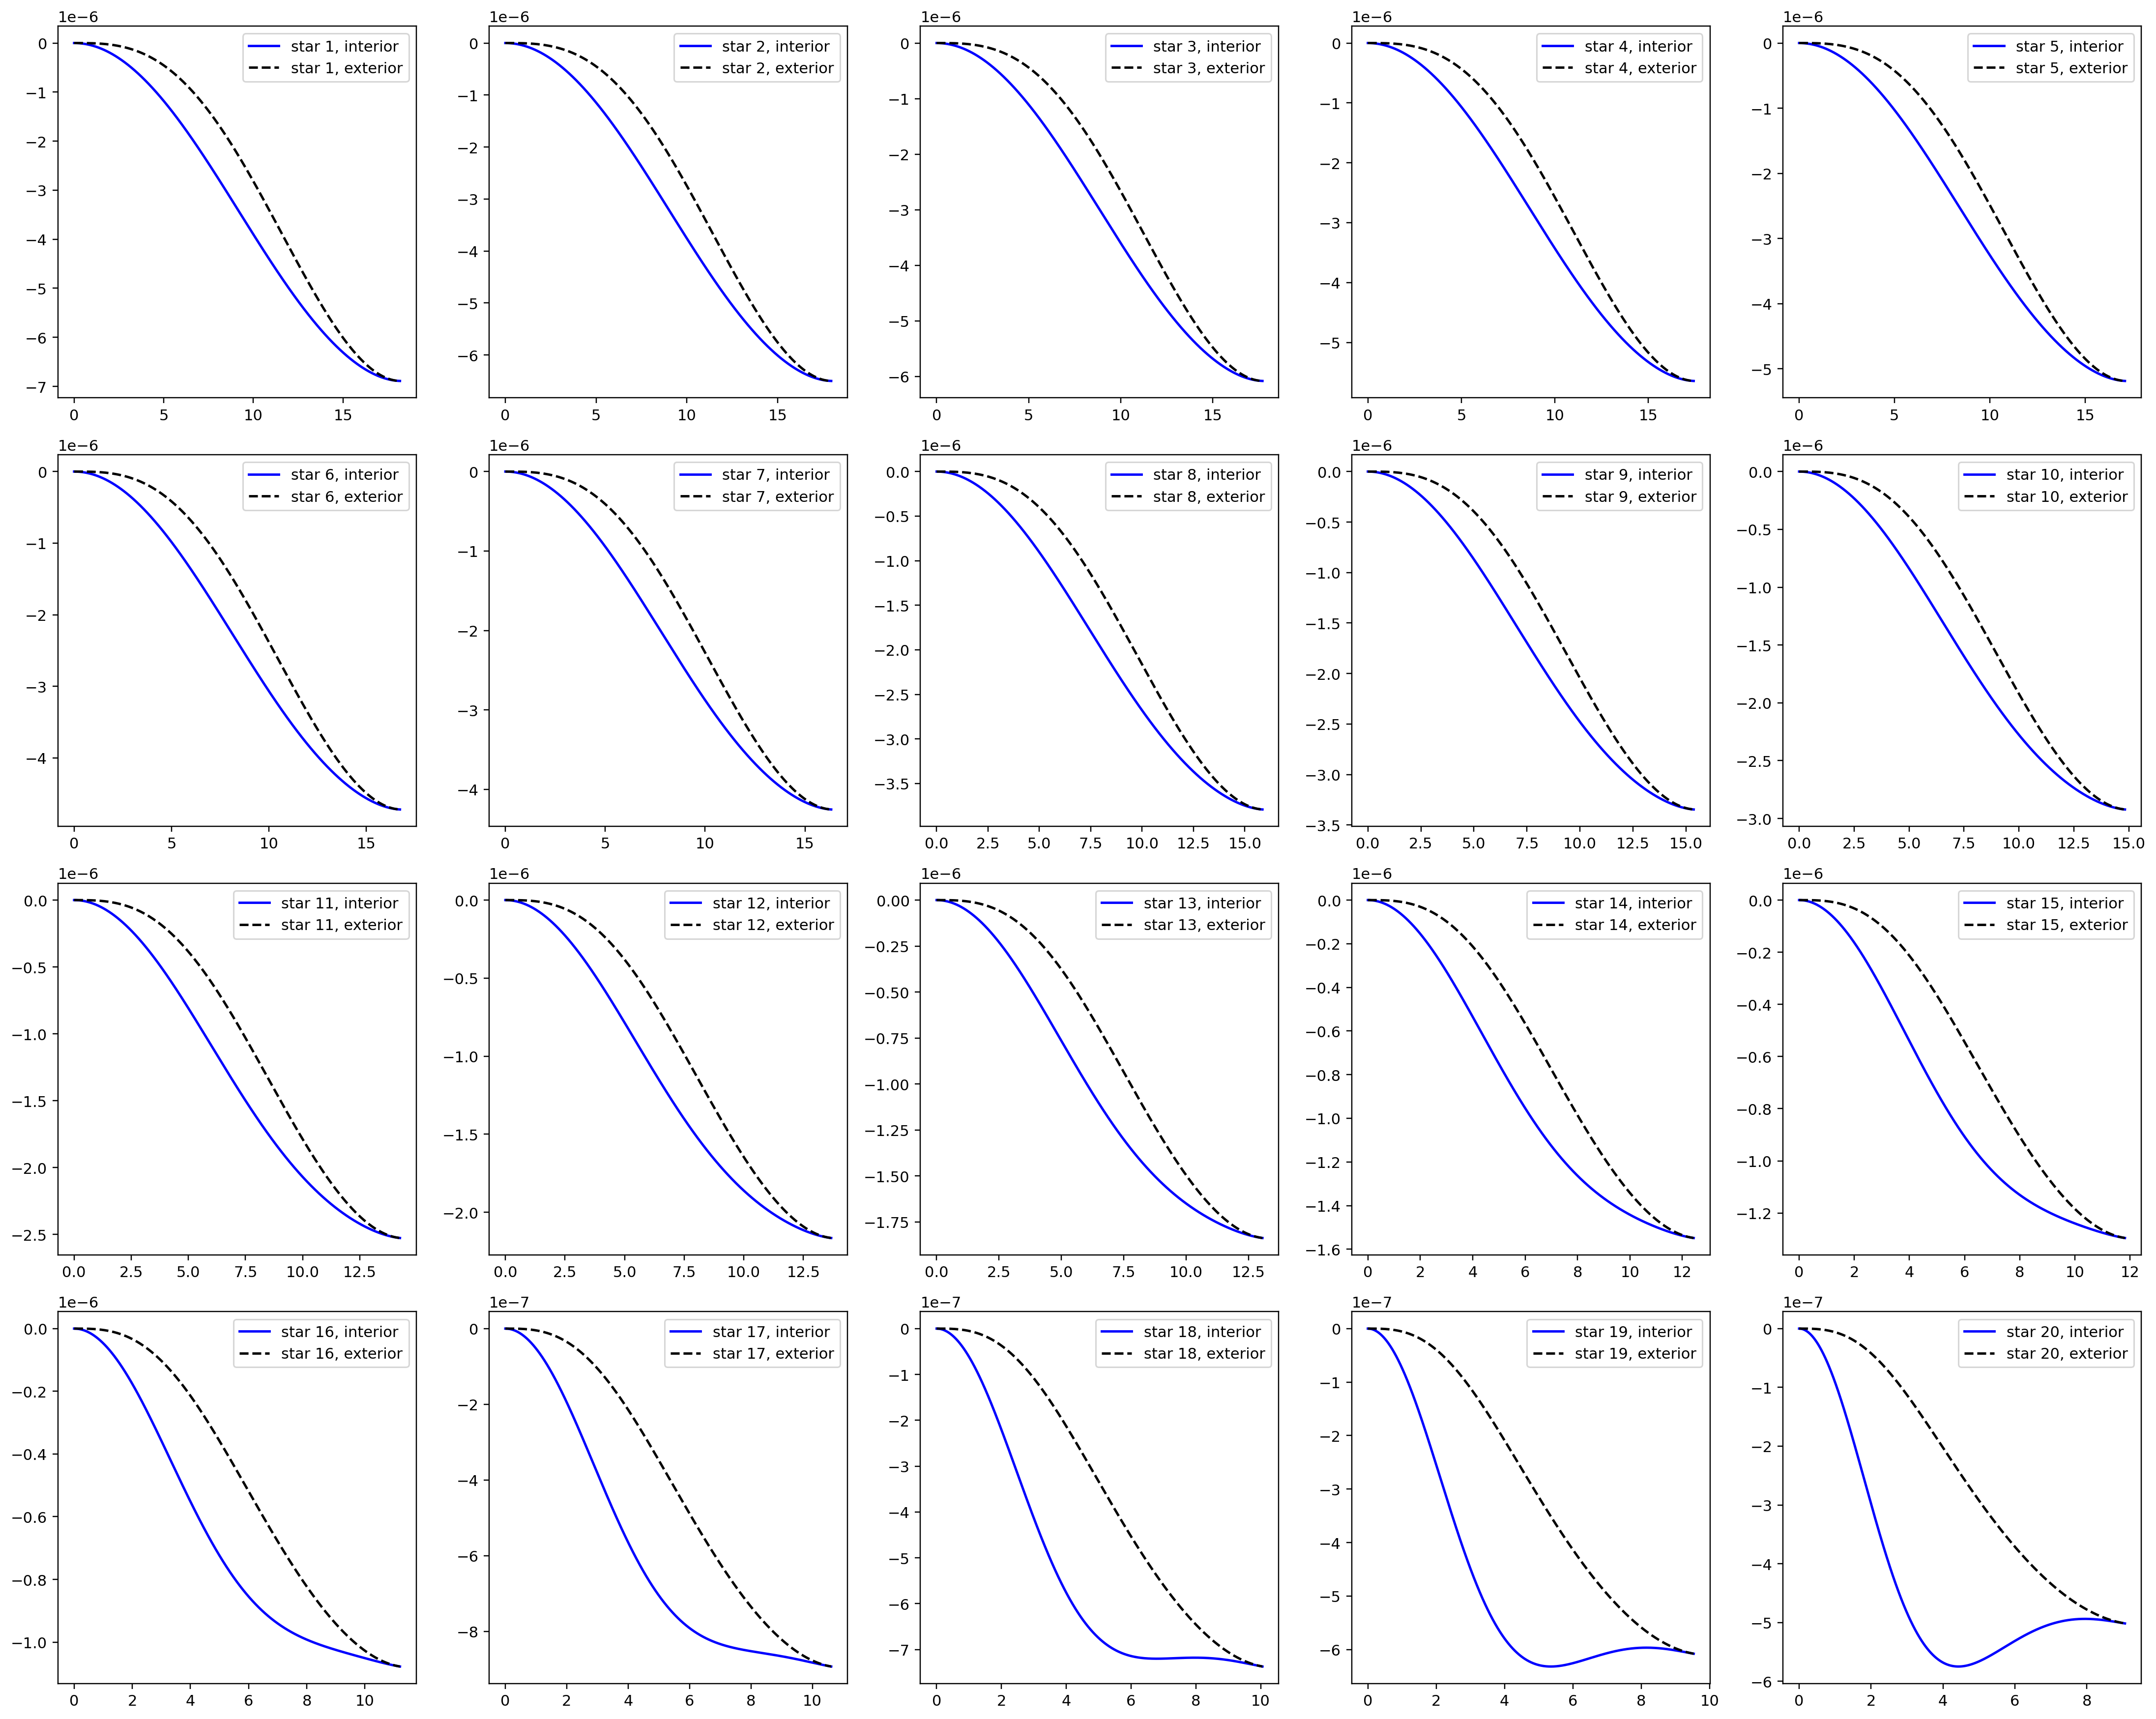

In [ ]:
fig, axs = plt.subplots(4, 5, figsize=(20, 16), dpi=220)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)
    ax = axs[nnn // 5, nnn % 5]

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    # Exterior Solution Unmatched
    ext_star = ExteriorGrid_1stOrder[solToUseID][:SurfaceIndex]
    ext_star_grad = ExteriorGrid_1stOrderP[solToUseID][:SurfaceIndex]

    # Interior homogeneous and particular unmatched
    h01_star_hom = H01Hom_Grid[solToUseID][:SurfaceIndex] 
    h01_star_part = H01Part_Grid[solToUseID][:SurfaceIndex] 

    # Solution to the boundary condition
    A0_star = A0_Arr[solToUseID]
    I2m_star = I2m_Arr[solToUseID]
    
    # Plotting interior (matched)
    ax.plot(
            RArr[:SurfaceIndex],
            A0_star * h01_star_hom[:,0] + h01_star_part[:,0],
            label=f"star {nnn + 1}, interior",
            color="blue",
            lw=1.6,
        )

    # Plotting exterior (matched)
    ax.plot(
        RArr[:SurfaceIndex],
        ext_star * I2m_star,
        label=f"star {nnn + 1}, exterior",
        color="black",
        lw=1.6,
        ls="--"
    )

    print(I2m_star)
    
    ax.legend()
    # ax.set_yscale("log")

fig.tight_layout()
plt.title
plt.show()


100%|██████████| 20/20 [00:00<00:00, 232.50it/s]


-8.842923821285081e-06
-7.24642118555107e-06
-5.931010491755828e-06
-4.849829829773168e-06
-3.963197387985191e-06
-3.238506483162975e-06
-2.647522846529915e-06
-2.1667787058282207e-06
-1.776584316209831e-06
-1.4602320981725952e-06
-1.2040449705167192e-06
-9.964184194681237e-07
-8.280493734910503e-07
-6.912205523670456e-07
-5.797347274605301e-07
-4.88575752969478e-07
-4.137728399824806e-07
-3.52182390273498e-07
-3.0131739418269397e-07
-2.592891742652915e-07


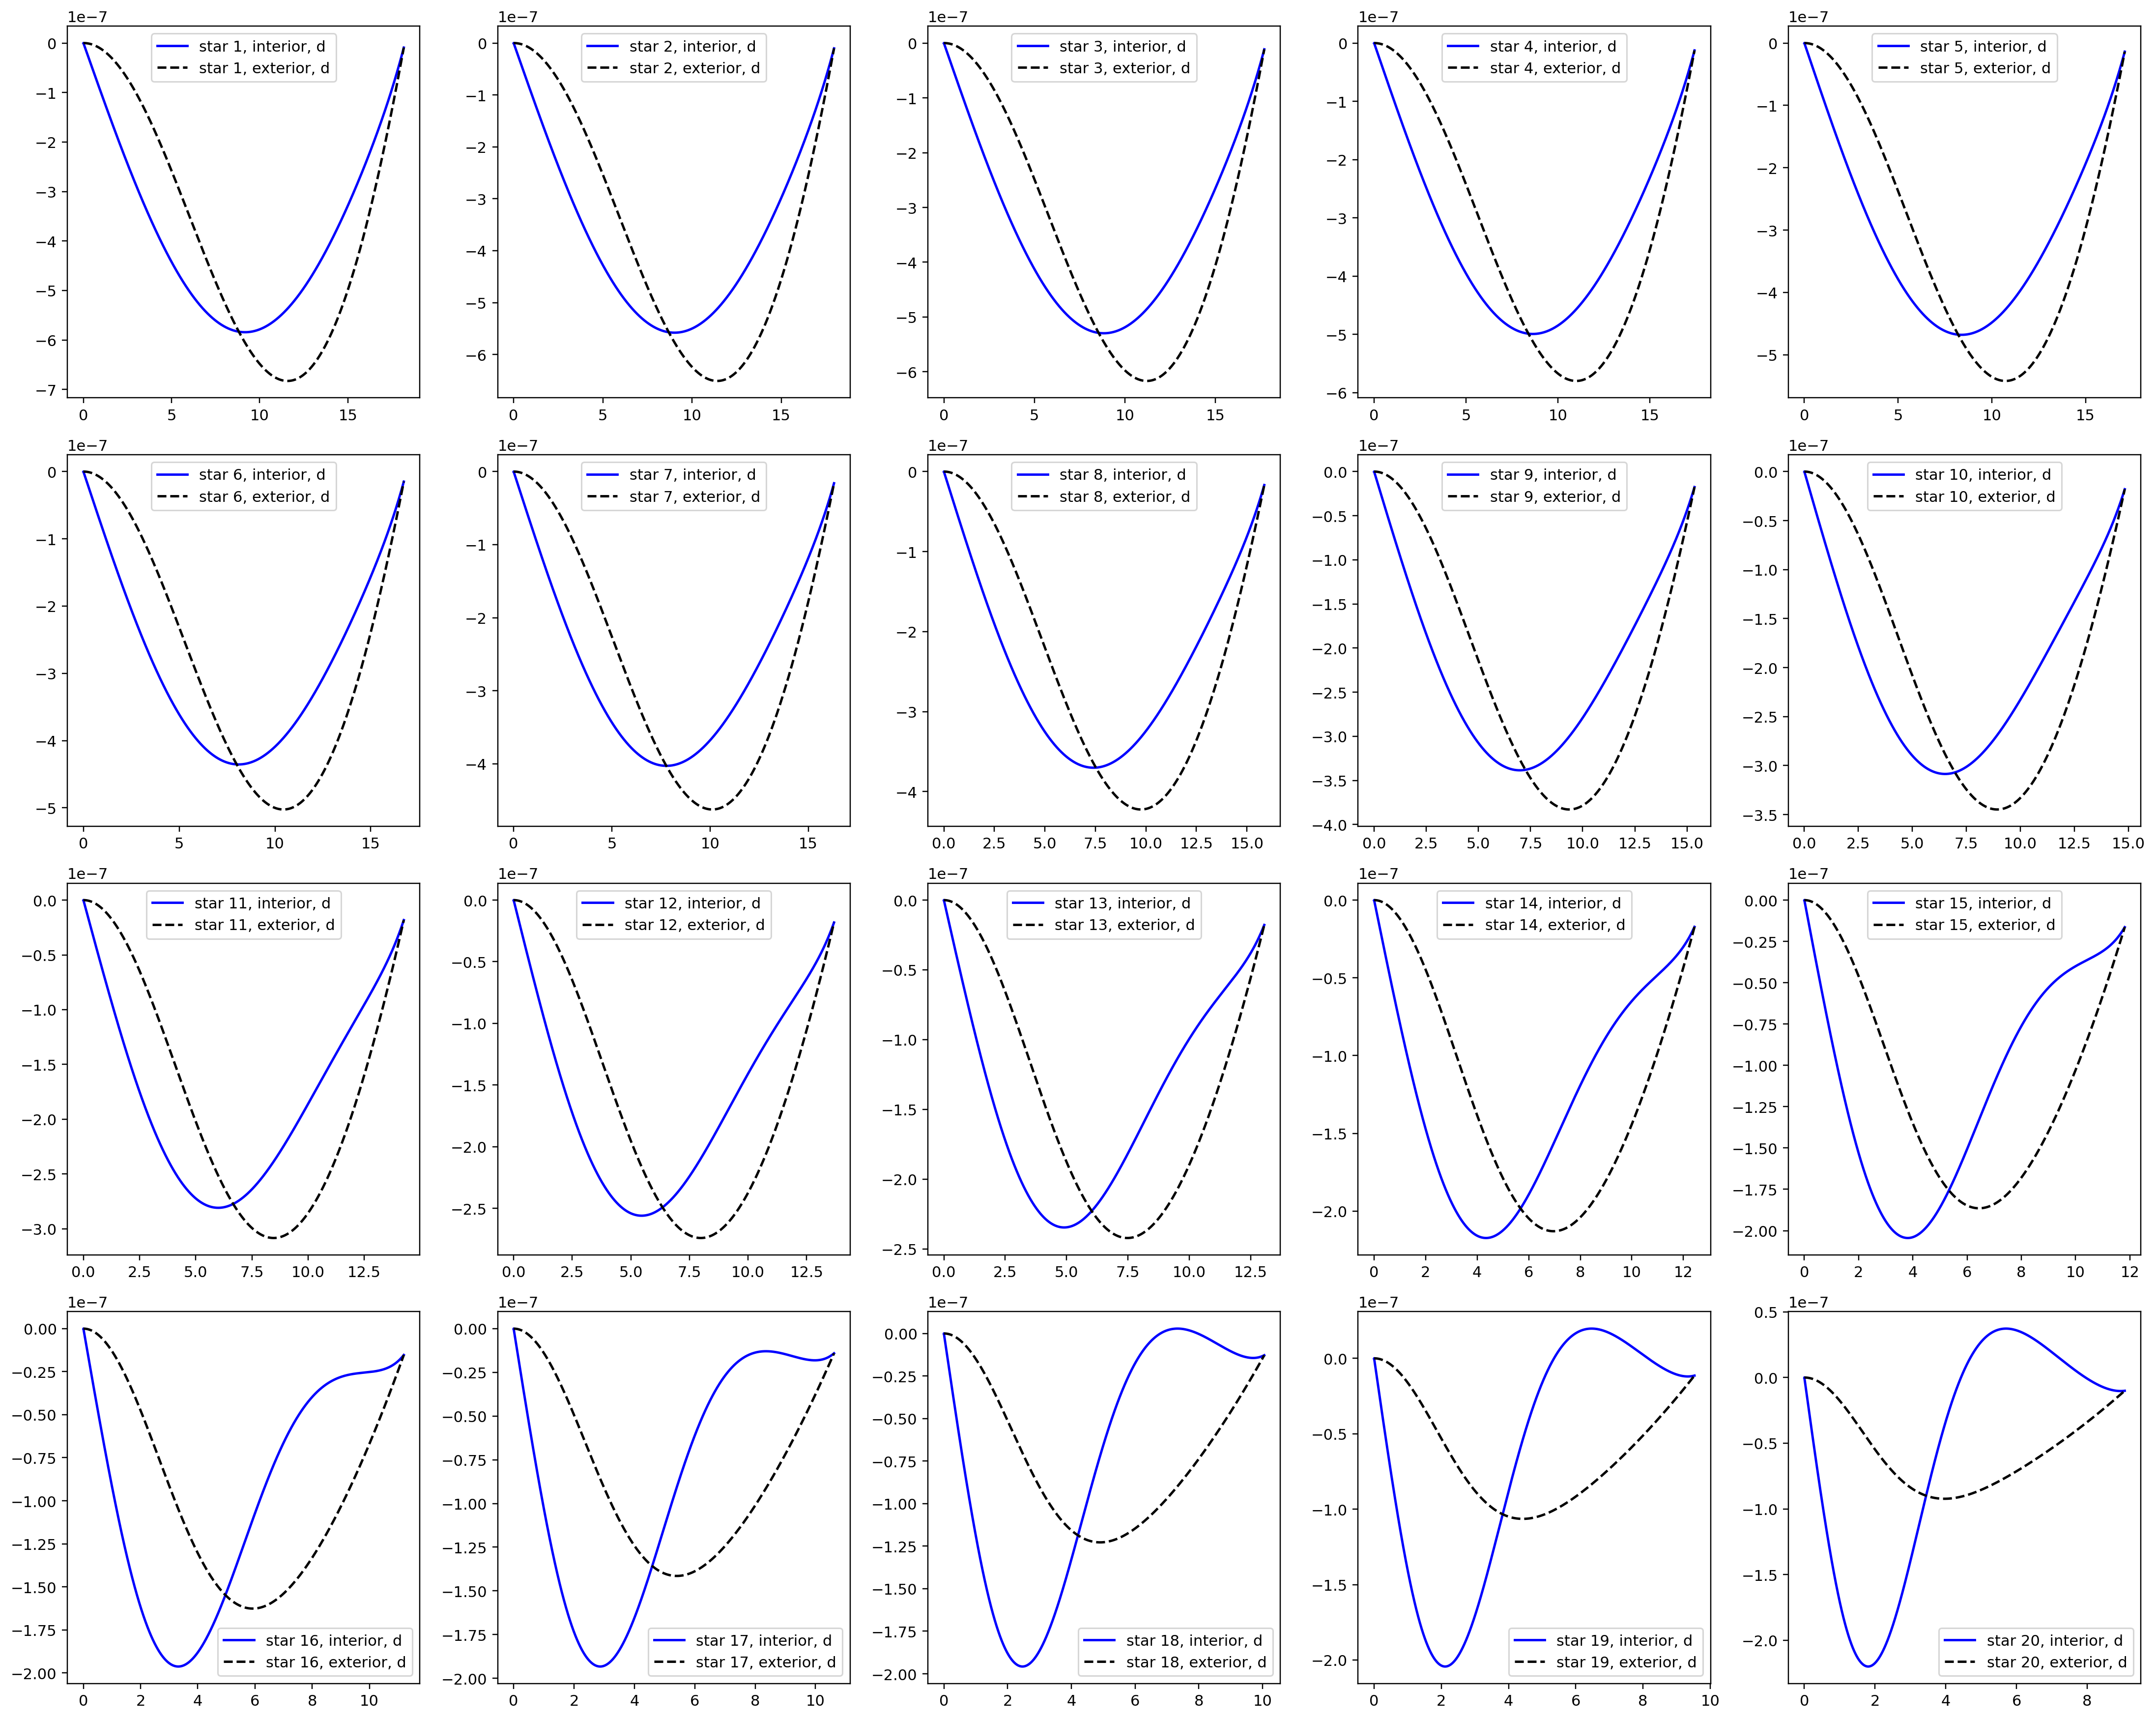

In [56]:
fig, axs = plt.subplots(4, 5, figsize=(20, 16), dpi=220)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)
    ax = axs[nnn // 5, nnn % 5]

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    # Exterior Solution Unmatched
    ext_star = ExteriorGrid_1stOrder[solToUseID][:SurfaceIndex]
    ext_star_grad = ExteriorGrid_1stOrderP[solToUseID][:SurfaceIndex]

    # Interior homogeneous and particular unmatched
    h01_star_hom = H01Hom_Grid[solToUseID][:SurfaceIndex] 
    h01_star_part = H01Part_Grid[solToUseID][:SurfaceIndex] 

    # Solution to the boundary condition
    A0_star = A0_Arr[solToUseID]
    I2m_star = I2m_Arr[solToUseID]
    
    # Plotting interior (matched)
    ax.plot(
            RArr[:SurfaceIndex],
            A0_star * h01_star_hom[:,1] + h01_star_part[:,1],
            label=f"star {nnn + 1}, interior, d",
            color="blue",
            lw=1.6,
        )

    # Plotting exterior (matched)
    ax.plot(
        RArr[:SurfaceIndex],
        ext_star_grad * I2m_star,
        label=f"star {nnn + 1}, exterior, d",
        color="black",
        lw=1.6,
        ls="--"
    )

    print(I2m_star)
    
    ax.legend()
    # ax.set_yscale("log")

fig.tight_layout()
plt.title
plt.show()


100%|██████████| 20/20 [00:00<00:00, 58.21it/s]


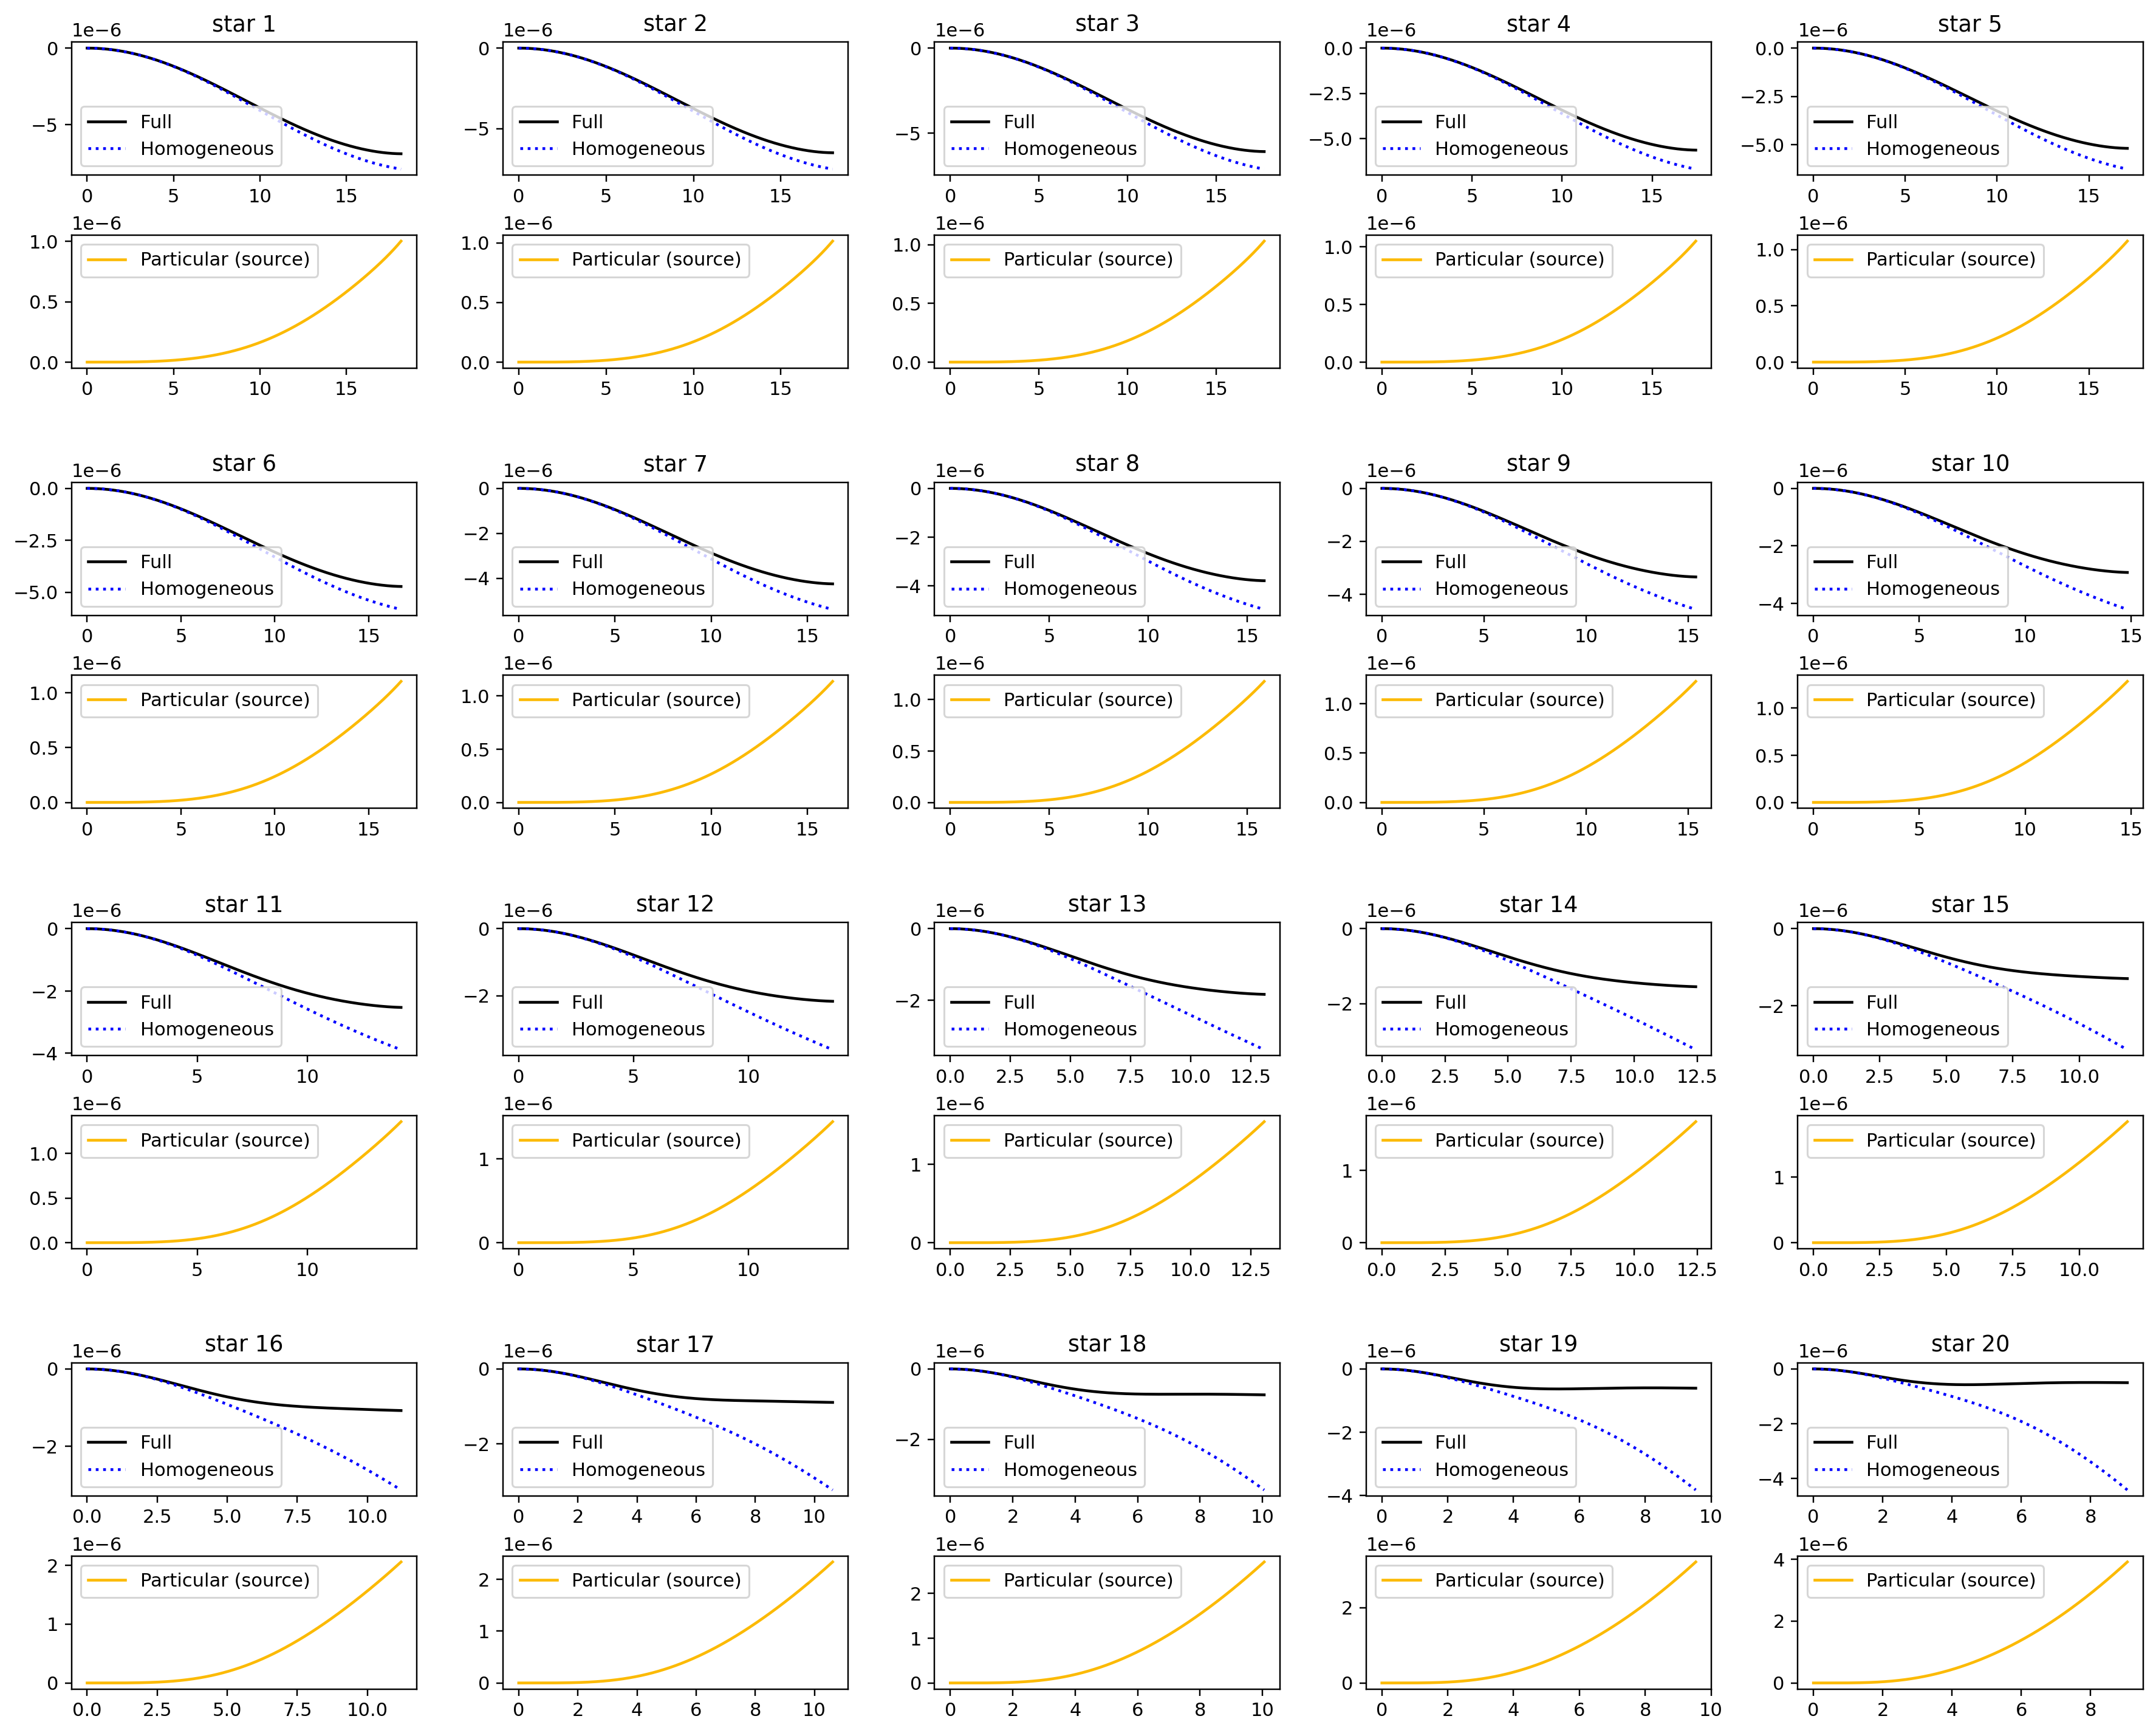

In [53]:
fig = plt.figure(figsize=(20, 16), dpi=220)
outer = fig.add_gridspec(4, 5, wspace=0.25, hspace=0.35)

for nnn in tqdm(range(0, 20)):
    solToUseID = nnn
    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    # ax = axs[nnn // 5, nnn % 5]

    # --- dividing in subplots ---
    inner = outer[nnn // 5, nnn % 5].subgridspec(
        2, 1, height_ratios=[1, 1], hspace=0.45
    )
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    # Solution to the boundary condition
    A0_star = A0_Arr[solToUseID]
    I2m_star = I2m_Arr[solToUseID]

    ax_top.plot(
        RArr[:SurfaceIndex],
        A0_star * H01Hom_Grid[solToUseID][:SurfaceIndex][:,0] + H01Part_Grid[solToUseID][:SurfaceIndex][:,0],
        label="Full",
        color="black",
        lw=1.5,
    )

    ax_top.plot(
        RArr[:SurfaceIndex],
        A0_star * H01Hom_Grid[solToUseID][:SurfaceIndex][:,0],
        label="Homogeneous",
        color="blue",
        ls = ":",
        lw=1.5,
    )
    ax_top.set_title(f"star {nnn+1}")
    # ax_top.set_yscale("log")
    ax_top.legend()

    ax_bot.plot(
        RArr[:SurfaceIndex],
        H01Part_Grid[solToUseID][:SurfaceIndex][:,0],
        label="Particular (source)",
        color="#fcba03",
        lw=1.5,
    )

    ax_bot.legend()


In [57]:
H01Sol_Grid_matched = []       # full / hom / particular 
H01Hom_Grid_matched = []
H01Part_Grid_matched = []

for nnn in tqdm(range(0, 20)):
    solToUseID = nnn

    # Solution to the boundary condition
    A0_star = A0_Arr[solToUseID]
    I2m_star = I2m_Arr[solToUseID]

    hom_matched = A0_star * H01Hom_Grid[solToUseID][:SurfaceIndex]
    part_matched = H01Part_Grid[solToUseID][:SurfaceIndex]
    full_matched = hom_matched + part_matched

    # Homogeneous
    H01Hom_Grid_matched.append(hom_matched)
    # Particular
    H01Part_Grid_matched.append(part_matched)
    # Full
    H01Sol_Grid_matched.append(full_matched)

100%|██████████| 20/20 [00:00<00:00, 1801.64it/s]


In [58]:
# Homogeneous
with open("./numpyArr/h01HomGrid.pkl", "wb") as f:                        
    pickle.dump(H01Hom_Grid_matched, f, protocol=pickle.HIGHEST_PROTOCOL)

# Particular
with open("./numpyArr/h01PartGrid.pkl", "wb") as f:                        
    pickle.dump(H01Part_Grid_matched, f, protocol=pickle.HIGHEST_PROTOCOL)    

# Full
with open("./numpyArr/h01FullGrid.pkl", "wb") as f:                        
    pickle.dump(H01Sol_Grid_matched, f, protocol=pickle.HIGHEST_PROTOCOL)